<a href="https://colab.research.google.com/github/liza-s-del/Sigareva_project/blob/pandas/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from google.colab import files
import pandas as pd

# Читаем наш датасет — один вызов, и вся таблица загружена!
df = pd.read_csv("5 train.csv")

print("Таблица загружена!")
print("Размер:", df.shape)

Таблица загружена!
Размер: (10886, 12)


In [16]:
# 1.Час суток с максимальным числом поездок в выходные дни

df_1 = df.copy()
df_1["datetime"] = pd.to_datetime(df_1["datetime"])

weekend_data = df_1[df_1["workingday"] == 0]
trips_by_hour = weekend_data.groupby(weekend_data["datetime"].dt.hour)["count"].mean()
max_hour = trips_by_hour.idxmax()

print(f"Час суток с максимальным числом поездок в выходные дни: {max_hour}")

Час суток с максимальным числом поездок в выходные дни: 13


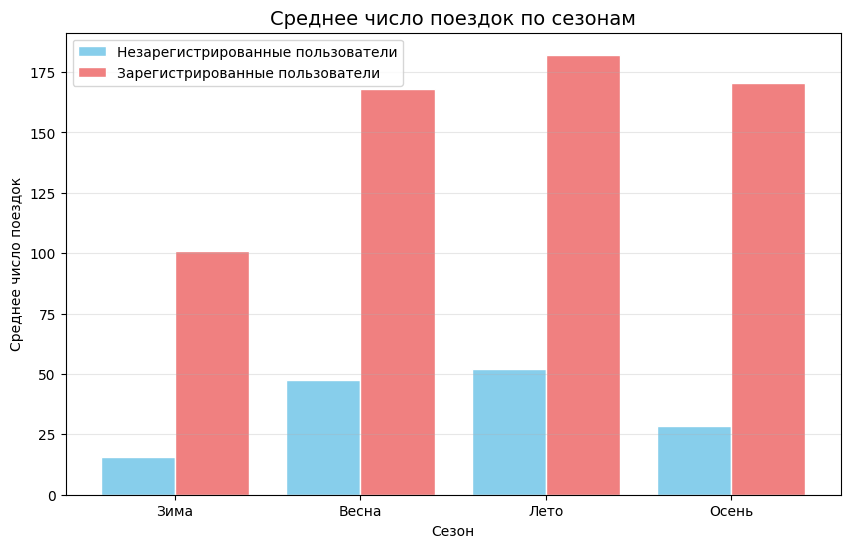

In [18]:
# 2. Построить столбчатую диаграмму - среднее число поездок для зарегестрированных и нет пользователей по сезонам

import matplotlib.pyplot as plt

seasonal_data = df_1.groupby("season")[["casual", "registered"]].mean()

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar([i - 0.2 for i in range(1, 5)], seasonal_data["casual"], width=0.4,
       label="Незарегистрированные пользователи", color="skyblue", edgecolor="white")
ax.bar([i + 0.2 for i in range(1, 5)], seasonal_data["registered"], width=0.4,
       label="Зарегистрированные пользователи", color="lightcoral", edgecolor="white")

ax.set_title("Среднее число поездок по сезонам", fontsize=14)
ax.set_xlabel("Сезон")
ax.set_ylabel("Среднее число поездок")
ax.set_xticks(range(1, 5))
ax.set_xticklabels(["Зима", "Весна", "Лето", "Осень"])
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.show()

In [29]:
# 3. Фильтр: найдите все наблюдения, где count > 500 - сколько их? В какое время года чаще всего?

high_rides = df[df["count"] > 500]
print("Наблюдений с count > 500:", len(high_rides))

season_counts = high_rides.groupby("season")["count"].count()
season_counts.index = ["Зима", "Весна", "Лето", "Осень"]

print("\nРаспределение по сезонам:")
print(season_counts)

print("\nЧаще всего поездок > 500 бывает:", season_counts.idxmax())

Наблюдений с count > 500: 797

Распределение по сезонам:
Зима      59
Весна    281
Лето     271
Осень    186
Name: count, dtype: int64

Чаще всего поездок > 500 бывает: Весна


In [17]:
# 4. Сохраните в CSV таблицу: средняя температура и среднее число поездок по каждому месяцу

monthly = df_1.groupby(df_1["datetime"].dt.month).agg({
    "temp": "mean",
    "count": "mean"
})
monthly.columns = ["Средняя температура", "Среднее число поездок"]
monthly.index.name = "Месяц"

monthly.to_csv("monthly_temp_rides.csv", sep=";")
print("Файл сохранён: monthly_temp_rides.csv")
print("\nРезультат:")
monthly

Файл сохранён: monthly_temp_rides.csv

Результат:


,Средняя температура,Среднее число поездок
Месяц,,
1,9.840000,90.366516
2,11.798535,110.003330
3,15.902175,148.169811
4,18.718372,184.160616
5,22.674079,219.459430
6,27.064496,242.031798
7,30.841711,235.325658
8,29.736689,234.118421
9,25.779032,233.805281
